# 587Ah 电芯膨胀力循环仿真案例

**电化学-力 双向耦合（路线 A）+ 耦合开关对照**

## 流程概述

1. 用 `params/params587.py` 的 587Ah LFP 参数搭建 DFN 老化模型（SEI / 析锂 / 颗粒力学 / 裂纹 SEI）；
2. **跑两遍**：耦合开（`SwellingCoupler`，力→孔隙率反馈）vs 耦合关（纯电化学），用于容量保持率对照；
3. 分块循环，每块结束算圈末膨胀力 → 面压 → 压缩各域孔隙率，再续跑；
4. 输出：膨胀力包络、真实孔隙率+面压、容量保持率（开/关）、放电容量。

> 横轴可在 `X_AXIS = "cycle" | "soh"` 间切换（第 2 步配置）；膨胀力图与孔隙率图均生效。
> `cycle` 模式下横轴 = 仿真圈 × t_factor（实测等效圈）。

In [2]:
# --- BatteryProject 路径自动定位 (无论从 root 还是 examples/ 启动 notebook 都能工作) ---
import sys
from pathlib import Path

_HERE = Path.cwd().resolve()
for _cand in (_HERE, *_HERE.parents):
    if (_cand / "src" / "easy_imports.py").exists() and (_cand / "pyproject.toml").exists():
        PROJECT_ROOT = _cand
        break
else:
    raise RuntimeError(f"Cannot locate BatteryProject root from {_HERE}")

WORKSPACE_ROOT = PROJECT_ROOT.parent
PARAMS_DIR = WORKSPACE_ROOT / "params"
for _p in (PROJECT_ROOT, WORKSPACE_ROOT, PARAMS_DIR):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

OUT_DIR = PROJECT_ROOT / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("PARAMS_DIR:  ", PARAMS_DIR)
print("OUT_DIR:     ", OUT_DIR)


PROJECT_ROOT: D:\Users\hez\Desktop\hithium\BatteryProject
PARAMS_DIR:   D:\Users\hez\Desktop\hithium\params
OUT_DIR:      D:\Users\hez\Desktop\hithium\BatteryProject\output


In [3]:
from src.easy_imports import (
    SwellingCoupler,
    apply_pybamm_runtime_limits,
    compute_cycle_energies,
    plot_swelling_coupling,
    run_aging_with_dryout,
)
from src.plotting import plot_analysis

apply_pybamm_runtime_limits()

import matplotlib.pyplot as plt
import numpy as np
import pybamm

from params587 import get_hithium_params  # 直接导入（params/ 在 sys.path）

pybamm.set_logging_level("WARNING")
print("依赖导入成功")

plt.style.use("science")
plt.rcParams["font.family"] = "Calibri, Microsoft YaHei"

依赖导入成功


## 第 1 步：构建老化模型和参数工厂

耦合器会就地压缩 `params` 的孔隙率，因此**每次运行都要新建一份 params 和 model**，保证开/关对照公平。

In [4]:
def build_aging_model() -> pybamm.BaseModel:
    options = {
        "SEI": "ec reaction limited",
        "SEI porosity change": "true",
        "lithium plating": "irreversible",
        "lithium plating porosity change": "true",
        "particle mechanics": ("swelling and cracking", "swelling only"),
        "SEI on cracks": "true",
        "loss of active material": "stress-driven",
        "contact resistance": "true",
    }
    return pybamm.lithium_ion.DFN(options)

def build_params(t_factor, temperature_k):
    # OKane2022 基座 + 587Ah 覆盖参数（每次新建，避免被耦合器就地改写污染）
    params = pybamm.ParameterValues("OKane2022")
    params.update(get_hithium_params(t_factor=t_factor, temperature=temperature_k),
                  check_already_exists=False)
    return params

_p = build_params(50, 298.15)
print(f"电芯展开尺寸: {_p['Electrode width [m]']:.2f} m × {_p['Electrode height [m]']:.3f} m")
print("（width 是卷绕展开长度，面压换算用壳体大面 area，见下）")

电芯展开尺寸: 98.92 m × 0.196 m
（width 是卷绕展开长度，面压换算用壳体大面 area，见下）


## 第 2 步：仿真与耦合配置

`X_AXIS` 控制膨胀力图 / 孔隙率图的横坐标。

In [5]:
# ---- 横轴切换："cycle"（实测等效圈）或 "soh"（容量保持率%）----
X_AXIS = "cycle"

# ---- 仿真规模 ----
N_BLOCKS = 80            # 分块数（每块后做一次力->孔隙率耦合）
CYCLES_PER_BLOCK = 2    # 每块循环数
C_RATE = 0.5            # 高倍率：孔隙率压缩→传输受限的效应在 3C 才显著（0.5~1C 可忽略）
TEMPERATURE_K = 298.15
T_FACTOR = 50           # 老化加速因子（= 实测圈/仿真圈，也是 acceleration_factor）

# ---- 力学/耦合参数 ----
# 注意：以下为【演示放大】参数——为让"力→孔隙率→容量"双向耦合效应肉眼可见，
# 刻意取高预紧力、小受力面（高面压）+ 偏软压缩模量 K_k。真实标定值
# （kPa 级面压、MPa 级 K_k）下耦合对容量影响很小，需高倍率/长周期才显现。
COUPLER_KW = dict(
    k_stiffness=1e9,            # 夹具刚度 (N/m)
    k_cell=5e9,                 # 电芯堆叠刚度 (N/m)，与夹具串联
    preload_force=20000.0,      # 初始预紧力 (N)，预紧面压≈500 kPa（高约束）
    beta_irreversible=0.5,      # 副反应产物顶出系数
    area=0.04,                  # 受力面面积 (m²)
    max_step_compression=0.15,  # 单块孔隙率最大压缩比例
    compaction_moduli={"negative electrode": 3e5, "separator": 1e5, "positive electrode": 3e5},
)

# ---- 求解器/网格/实验 ----
solver = pybamm.IDAKLUSolver(rtol=1e-6, atol=1e-6)
var_pts = {"x_n": 5, "x_s": 5, "x_p": 5, "r_n": 10, "r_p": 10}

def make_experiment(cycles_per_block):
    step = (
        f"Charge at {C_RATE}C until 3.65 V (2 minute period)",
        "Rest for 10 minutes (2 minute period)",
        f"Discharge at {C_RATE}C until 2.5 V (2 minute period)",
        "Rest for 10 minutes (2 minute period)",
    )
    return pybamm.Experiment([step] * cycles_per_block, temperature=TEMPERATURE_K)

print(f"总仿真圈: {N_BLOCKS * CYCLES_PER_BLOCK}  ≈  实测等效 {N_BLOCKS * CYCLES_PER_BLOCK * T_FACTOR} 圈；横轴 = {X_AXIS}")

总仿真圈: 160  ≈  实测等效 8000 圈；横轴 = cycle


## 第 3 步：运行两遍仿真（耦合开 / 关）

耗时步骤。耦合开返回 `(sol_list, coupler)`；耦合关传 `swelling_coupler=None`，纯电化学基线。

In [6]:
def run_simulation(use_swelling_coupling: bool):
    # 跑一次分块老化仿真。返回 (sol_list, coupler_or_None)
    model = build_aging_model()
    params = build_params(T_FACTOR, TEMPERATURE_K)
    coupler = SwellingCoupler(params, **COUPLER_KW) if use_swelling_coupling else None

    sol_list = run_aging_with_dryout(
        model, params, make_experiment, solver, var_pts,
        swelling_coupler=coupler,
        n_blocks=N_BLOCKS, cycles_per_block=CYCLES_PER_BLOCK,
        t_factor=T_FACTOR, temperature=TEMPERATURE_K,
        showprogress=False,
    )
    return sol_list, coupler

print(">>> 运行【耦合开】...")
sol_on, coupler = run_simulation(use_swelling_coupling=True)

print(">>> 运行【耦合关】（基线）...")
sol_off, _ = run_simulation(use_swelling_coupling=False)

print(f"完成：耦合开累积 {len(sol_on[-1].cycles)} 圈，耦合关累积 {len(sol_off[-1].cycles)} 圈")

>>> 运行【耦合开】...

=== Block 1/80 ===

=== Block 2/80 ===

=== Block 3/80 ===

=== Block 4/80 ===

=== Block 5/80 ===

=== Block 6/80 ===

=== Block 7/80 ===

=== Block 8/80 ===

=== Block 9/80 ===

=== Block 10/80 ===

=== Block 11/80 ===

=== Block 12/80 ===

=== Block 13/80 ===

=== Block 14/80 ===

=== Block 15/80 ===

=== Block 16/80 ===

=== Block 17/80 ===

=== Block 18/80 ===

=== Block 19/80 ===

=== Block 20/80 ===

=== Block 21/80 ===

=== Block 22/80 ===

=== Block 23/80 ===

=== Block 24/80 ===

=== Block 25/80 ===

=== Block 26/80 ===

=== Block 27/80 ===

=== Block 28/80 ===

=== Block 29/80 ===

=== Block 30/80 ===

=== Block 31/80 ===

=== Block 32/80 ===

=== Block 33/80 ===

=== Block 34/80 ===

=== Block 35/80 ===

=== Block 36/80 ===

=== Block 37/80 ===

=== Block 38/80 ===

=== Block 39/80 ===

=== Block 40/80 ===

=== Block 41/80 ===

=== Block 42/80 ===

=== Block 43/80 ===

=== Block 44/80 ===

=== Block 45/80 ===

=== Block 46/80 ===

=== Block 47/80 ===

=== Bl

## 第 4 步：耦合摘要

In [7]:
print("=== 膨胀力-孔隙率耦合摘要 ===")
coupler.summary()

=== 膨胀力-孔隙率耦合摘要 ===
  EOC 膨胀力: 20000.0 -> 25502.1 N
  面压:       500.000 -> 637.554 kPa
  孔隙率 ε_n: 0.3217 -> 0.2027
  孔隙率 ε_s: 0.4000 -> 0.0989
  孔隙率 ε_p: 0.2342 -> 0.1476


## 第 5 步：膨胀力包络 + 真实孔隙率/面压（库函数 `plot_swelling_coupling`）

左=力包络（max/min/EOC，填充为呼吸幅值带），右=真实孔隙率状态量（随 SEI/析锂堵孔下跌，孔隙率损失主因）+ 耦合面压（红虚线，力学二阶量）。
横轴随 `X_AXIS` 在 cycle / SOH 间切换（SOH 模式自动反转）；力模型参数与耦合器一致（`**coupler.swelling_kwargs`）。

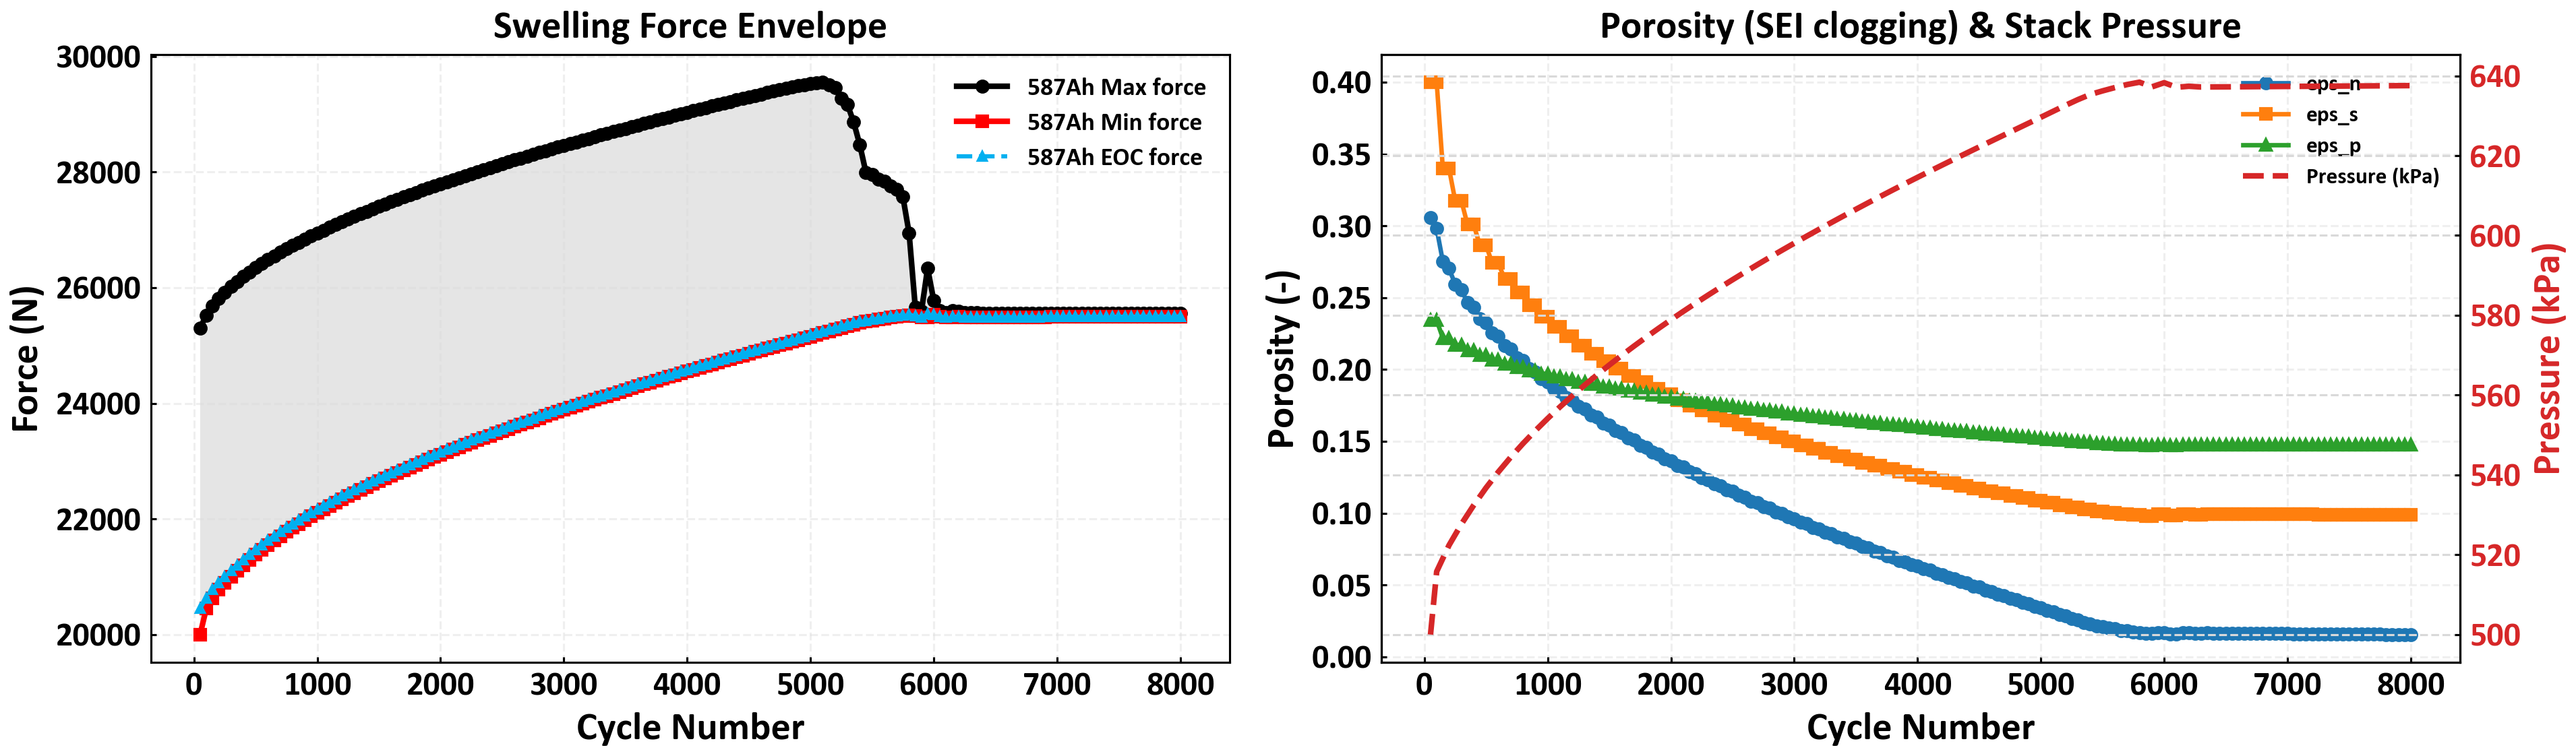

说明：右图实线随 SEI/析锂堵孔下跌（孔隙率损失主因）；红虚线面压为力学二阶量，kPa 级下很小。


In [8]:
result = plot_swelling_coupling(
    sol_on[-1], "587Ah", build_params(T_FACTOR, TEMPERATURE_K),
    x_axis=X_AXIS,
    acceleration_factor=T_FACTOR,
    pressure_history=coupler.history["pressure_pa"],
    cycles_per_block=CYCLES_PER_BLOCK,
    **coupler.swelling_kwargs,
)
fig, (ax1, ax2) = result
fig.savefig(str(OUT_DIR / "swelling_cycling_coupling.png"), dpi=150, bbox_inches="tight")
plt.show()
print("说明：右图实线随 SEI/析锂堵孔下跌（孔隙率损失主因）；红虚线面压为力学二阶量，kPa 级下很小。")

## 第 7 步：容量保持率 + 放电容量（耦合开 vs 关，并排）

左=容量保持率（每圈放电容量/首圈），右=放电容量绝对值；均为耦合开/关对比。
高倍率(3C)下孔隙率压缩恶化电解液传输，耦合开的容量衰减明显更快。

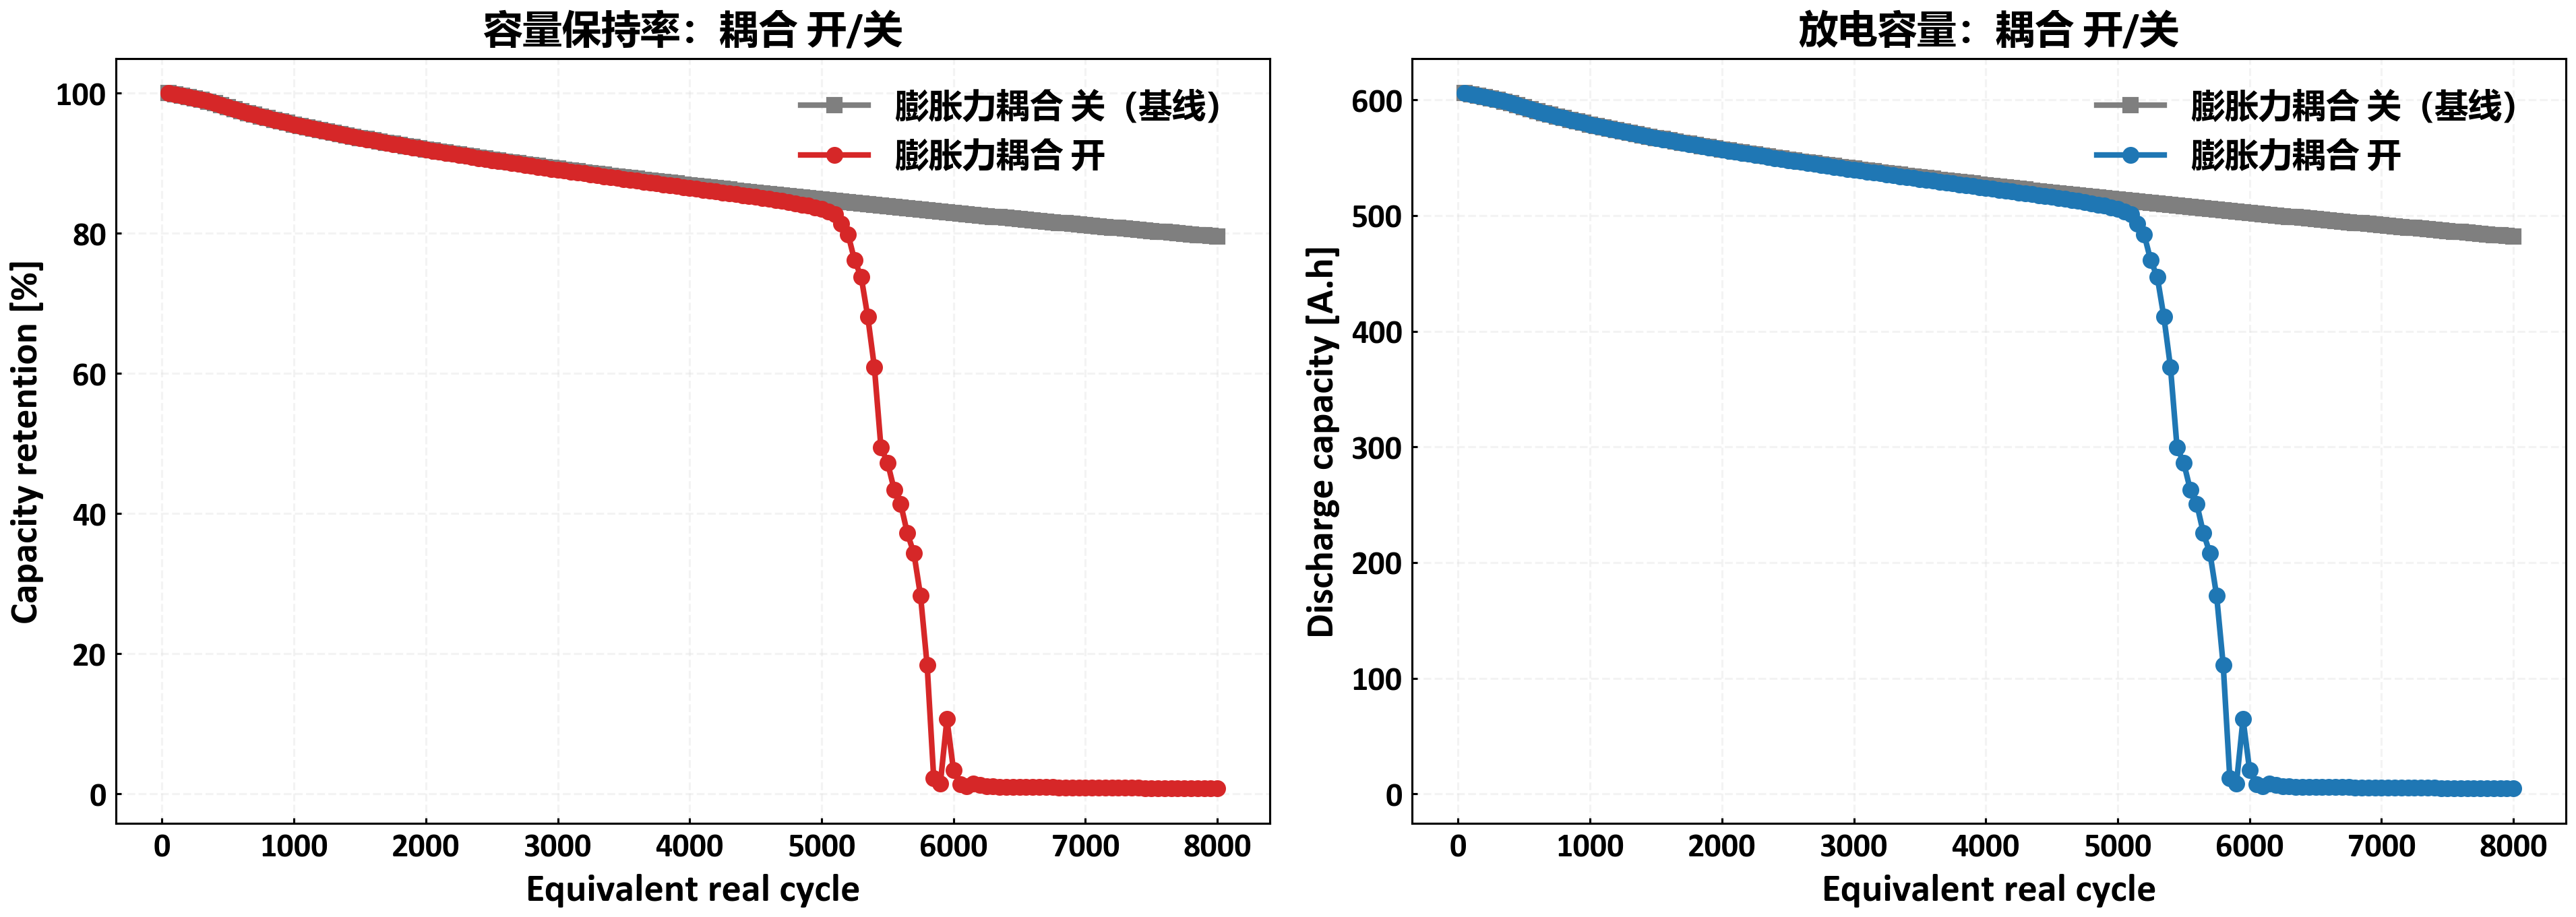

末点保持率：开 0.79%  vs  关 79.54%  (差 78.75 pp)
最大保持率偏差: 81.64 个百分点


In [10]:
def _cap_curves(sol_list):
    res = compute_cycle_energies(sol_list[-1])
    cap, idx = res["discharge_cap"], res["cycle_index"]
    if cap.size == 0:
        return np.array([]), np.array([]), np.array([])
    x = (idx + 1) * T_FACTOR
    return x, cap, cap / cap[0] * 100.0

x_on, cap_on, ret_on = _cap_curves(sol_on)
x_off, cap_off, ret_off = _cap_curves(sol_off)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))

# 左：容量保持率
axL.plot(x_off, ret_off, "s-", color="tab:gray", lw=2, ms=5, label="膨胀力耦合 关（基线）")
axL.plot(x_on, ret_on, "o-", color="tab:red", lw=2, ms=5, label="膨胀力耦合 开")
axL.set_xlabel("Equivalent real cycle")
axL.set_ylabel("Capacity retention [%]")
axL.set_title("容量保持率：耦合 开/关")
axL.legend(); axL.grid(alpha=0.3, ls="--")

# 右：放电容量
axR.plot(x_off, cap_off, "s-", color="tab:gray", lw=2, ms=5, label="膨胀力耦合 关（基线）")
axR.plot(x_on, cap_on, "o-", color="tab:blue", lw=2, ms=5, label="膨胀力耦合 开")
axR.set_xlabel("Equivalent real cycle")
axR.set_ylabel("Discharge capacity [A.h]")
axR.set_title("放电容量：耦合 开/关")
axR.legend(); axR.grid(alpha=0.3, ls="--")

fig.tight_layout()
fig.savefig(str(OUT_DIR / "swelling_cycling_capacity_retention.png"), dpi=150, bbox_inches="tight")
plt.show()

if ret_on.size and ret_off.size:
    n = min(len(ret_on), len(ret_off))
    print(f"末点保持率：开 {ret_on[-1]:.2f}%  vs  关 {ret_off[-1]:.2f}%  (差 {abs(ret_on[-1]-ret_off[-1]):.2f} pp)")
    print(f"最大保持率偏差: {np.max(np.abs(ret_on[:n] - ret_off[:n])):.2f} 个百分点")

## 标定工作流

1. **采集实测**：587Ah 多温度/倍率膨胀力曲线（恒间隙 load cell 夹具）+ 膨胀仪/CT 孔隙率；
2. **标定**：用 `compare_swelling` 拟合 `k_stiffness/k_cell/preload_force/beta_irreversible/expansion_function_*`，用孔隙率数据标定各域压缩模量 `K_k`，确认受力面 `area`；
3. **验证**：标定后重跑本案例，对比仿真孔隙率/保持率与实测；
4. **应用**：长周期寿命预测、夹具预紧力设计。

> 当前 kPa 级面压下力学耦合对孔隙率/保持率影响很小属正常——压缩模量 `K_k` 与真实面压须按实测标定后才显现。

## 老化内部参数展示

`plot_analysis` 综合面板（2×4）逐方案展示老化机理内参：SOH 衰减、充放电曲线、
负极电解液最小浓度（干涸/传输受限）、析锂过电位、充电末端表面计量比、析锂项分解、
活性锂损失(LLI)、孔隙率分布。对比【耦合开】vs【耦合关】可看力→孔隙率耦合对各机理的影响。



=== 老化内部参数：耦合开 ===


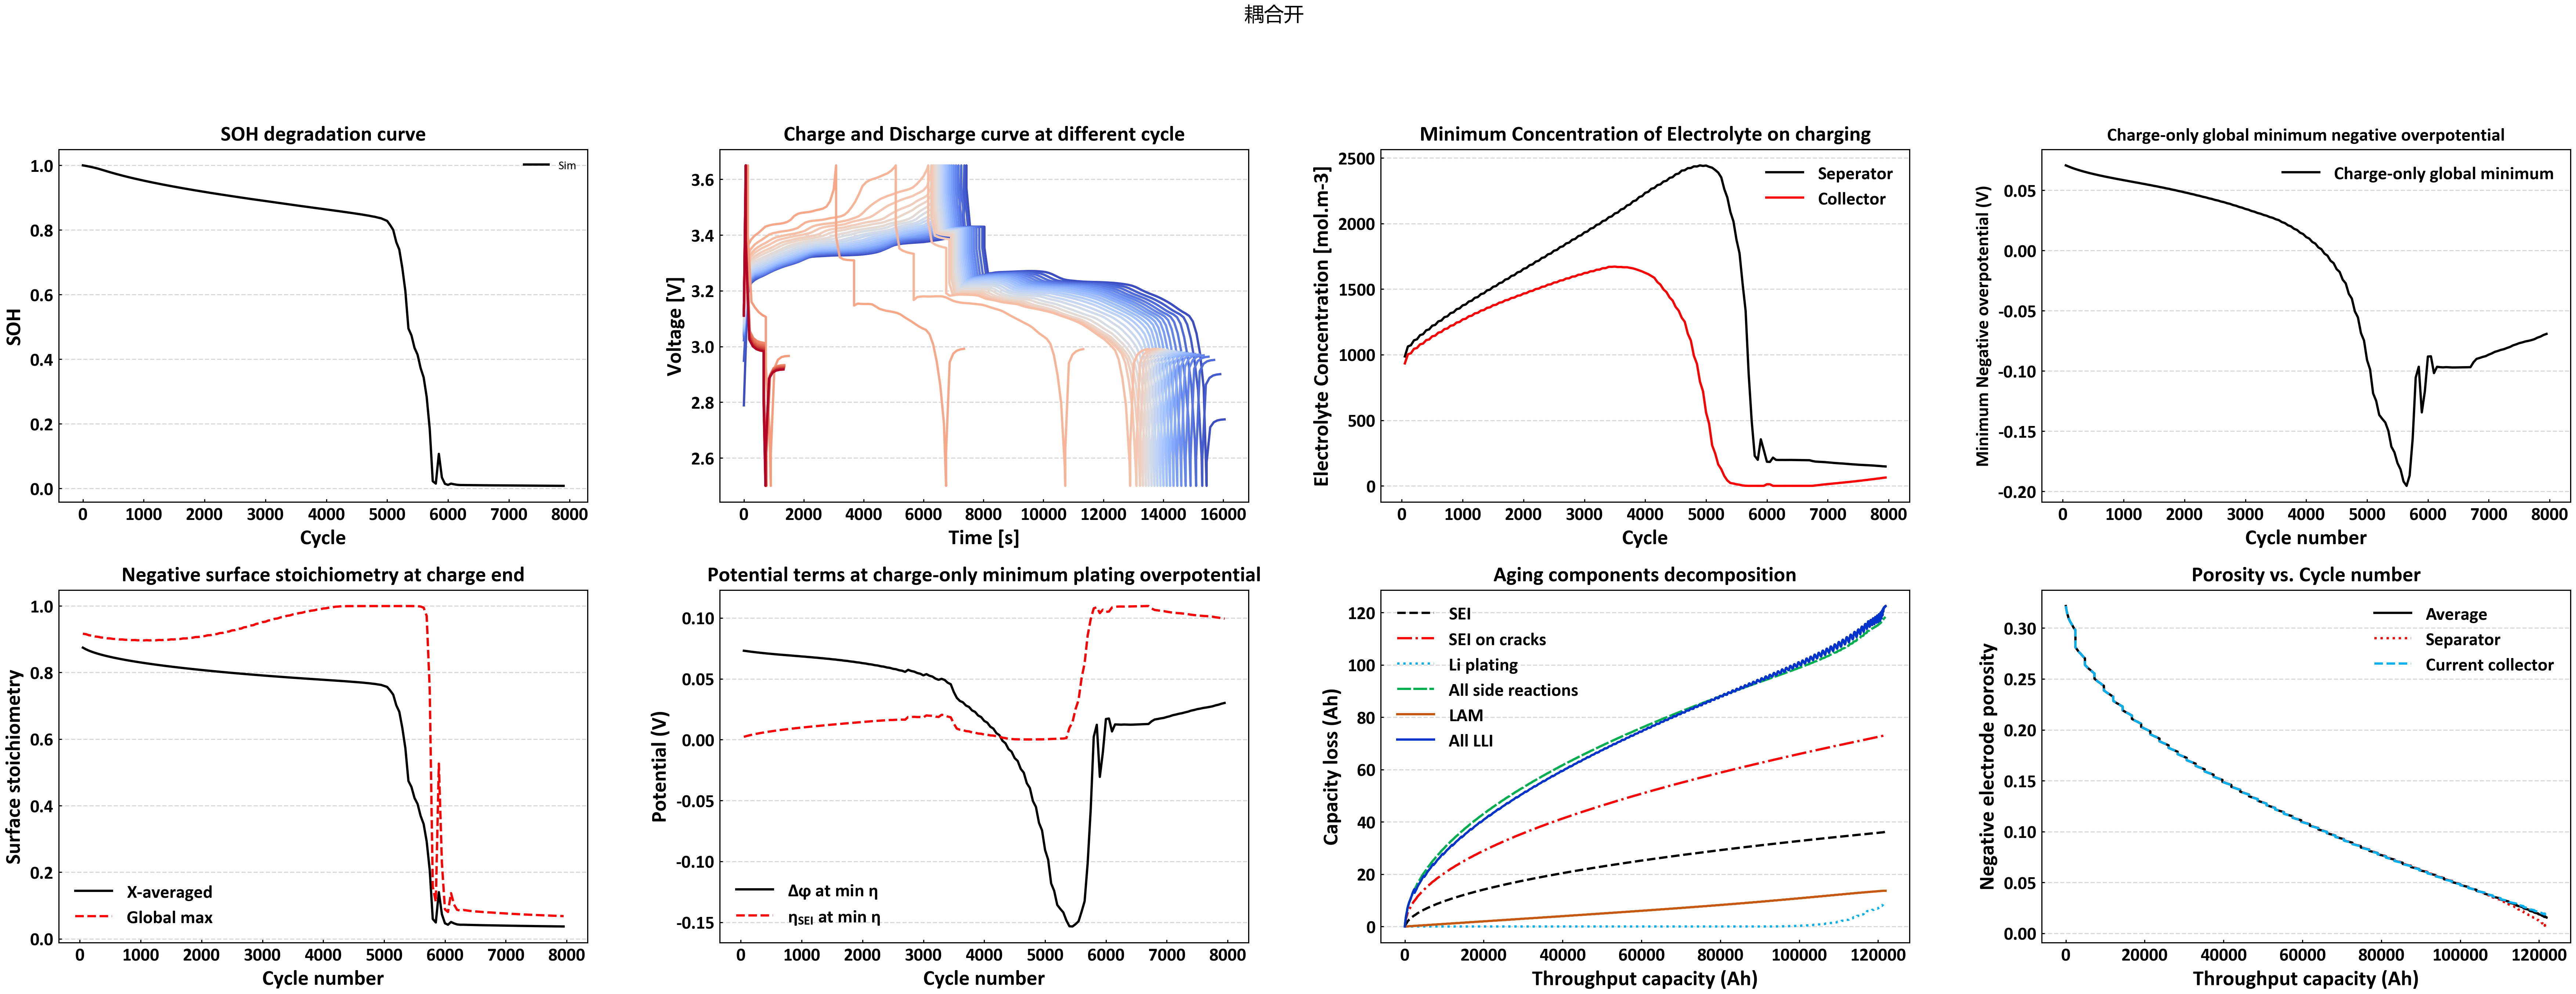


=== 老化内部参数：耦合关（基线） ===


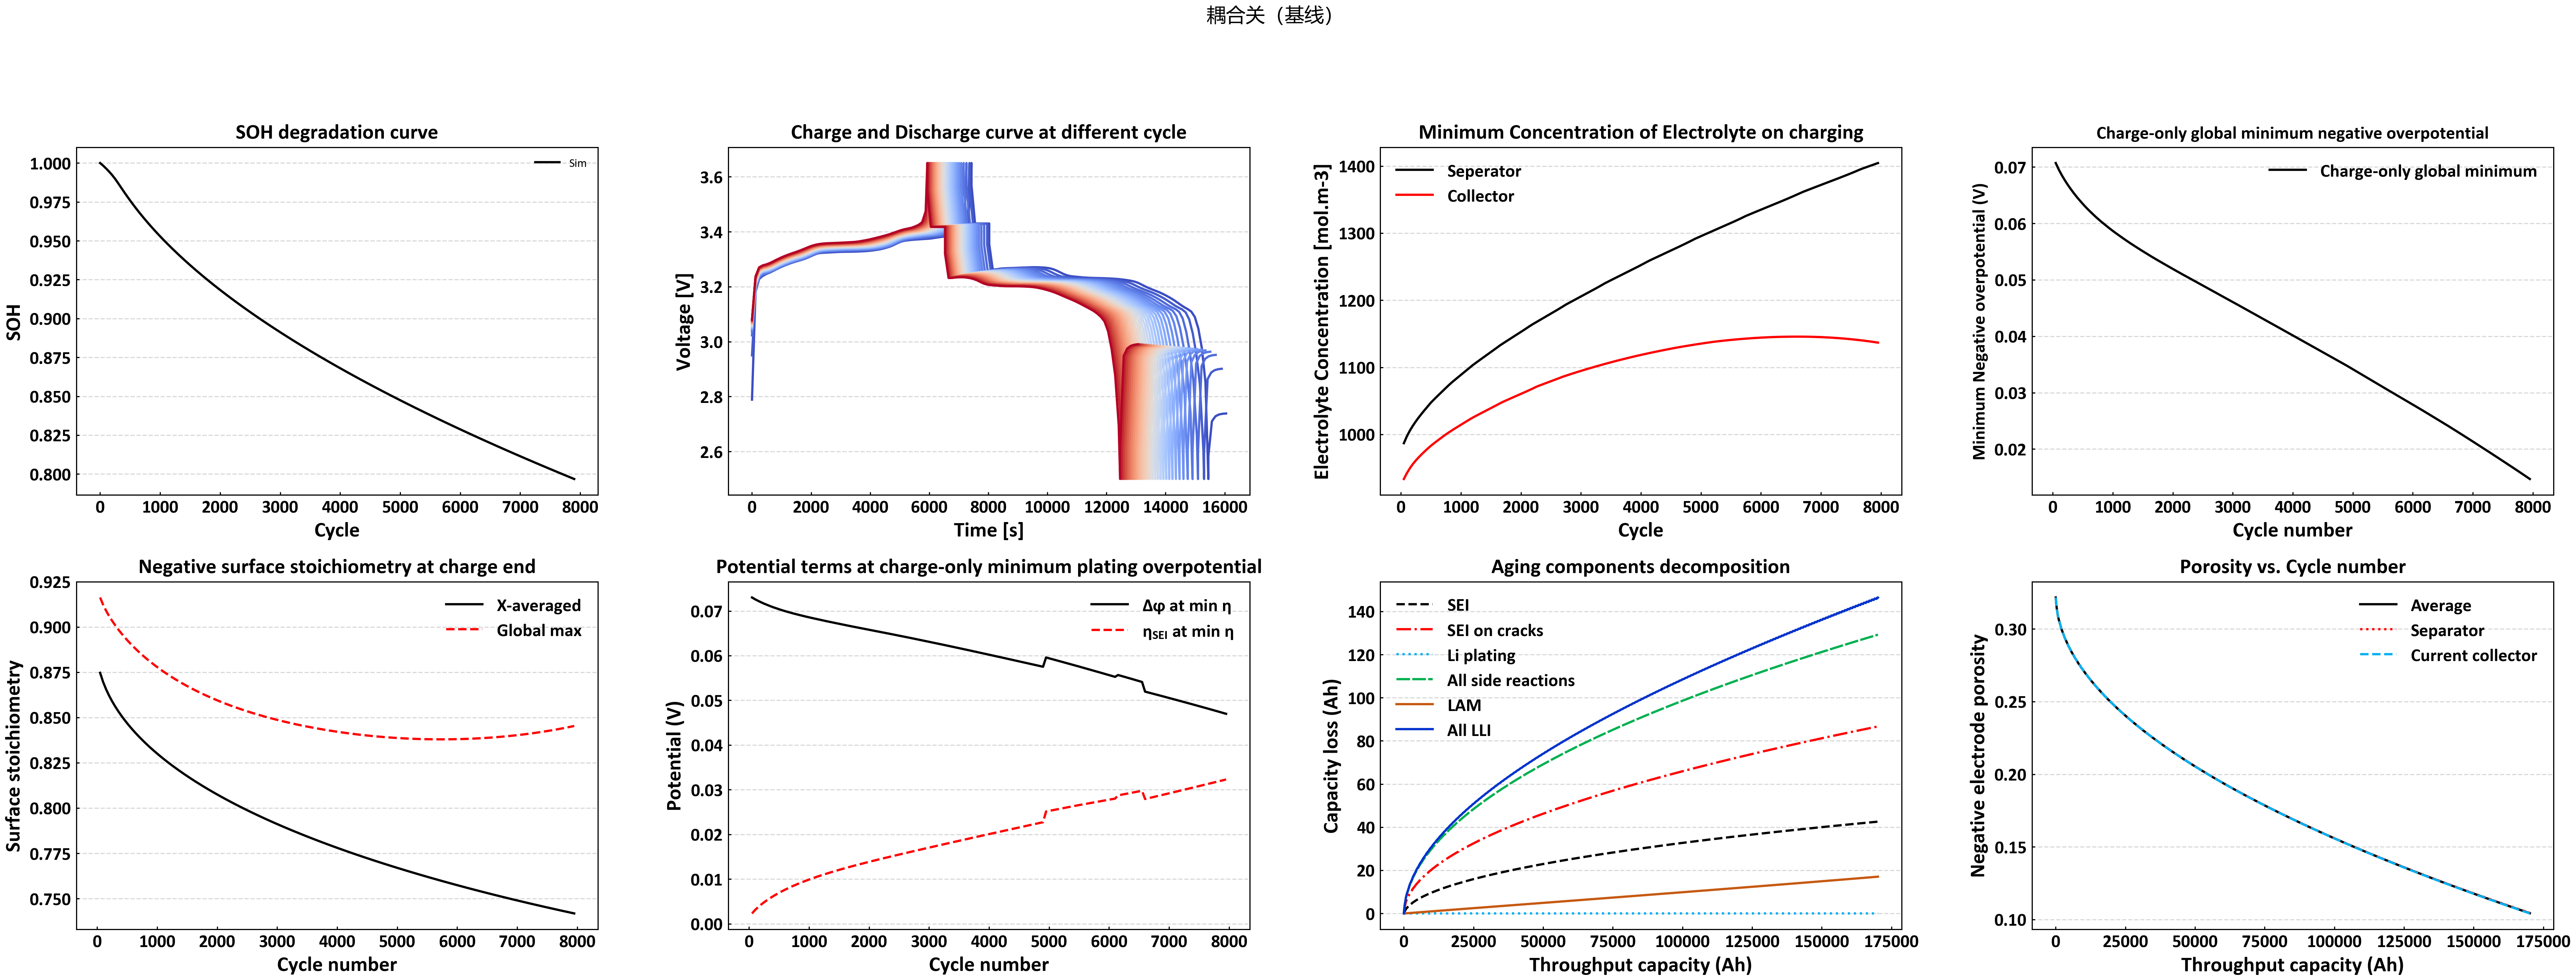

In [11]:
cases = [("耦合开", sol_on[-1]), ("耦合关（基线）", sol_off[-1])]
for label, sol in cases:
    print(f"\n=== 老化内部参数：{label} ===")
    fig, _ = plot_analysis(sol, t_factor=T_FACTOR)
    fig.suptitle(label, y=1.02, fontsize=13)
    tag = "on" if label == "耦合开" else "off"
    fig.savefig(str(OUT_DIR / f"swelling_internals_{tag}.png"), dpi=150, bbox_inches="tight")
    plt.show()
